# 01 — Simulation of Confounding Bias

**Goal.** This notebook illustrates a basic causal inference problem: a treatment `A` appears to have an effect on an outcome `Y`, but part of this association is due to a confounder `X`.

## Causal idea

A variable `X` is a **confounder** if:

1. `X` affects the treatment assignment `A`;
2. `X` also affects the outcome `Y`.

If we compare treated and untreated individuals without accounting for `X`, the estimated effect can be biased.

We simulate data where the true average treatment effect is known:

$$
Y = \beta_0 + \tau A + \gamma X + \varepsilon.
$$

Here, the true causal effect is:

$$
ATE = \tau.
$$

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression, LogisticRegression

FIG_DIR = Path("figures")
RES_DIR = Path("results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def summarize_estimates(estimates, true_ate):
    return pd.DataFrame([
        {
            "Estimator": name,
            "Estimate": value,
            "True ATE": true_ate,
            "Bias": value - true_ate,
            "Absolute error": abs(value - true_ate),
        }
        for name, value in estimates.items()
    ])

## 1. Data-generating process

We generate a population with:

- `X`: baseline covariate/confounder;
- `A`: binary treatment;
- `Y`: continuous outcome;
- `tau`: true causal effect of the treatment.

Treatment assignment depends on `X`, and the outcome also depends on `X`. Therefore, `X` is a confounder.

In [9]:
def simulate_confounded_data(n=5000, tau=2.0, beta0=1.0, gamma=1.5,
                             treatment_intercept=-0.2, treatment_slope=1.3,
                             noise_sd=1.0, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, n)
    p_treat = sigmoid(treatment_intercept + treatment_slope * X)
    A = rng.binomial(1, p_treat, n)
    eps = rng.normal(0, noise_sd, n)
    Y = beta0 + tau * A + gamma * X + eps
    return pd.DataFrame({"X": X, "A": A, "Y": Y, "true_propensity": p_treat})

TRUE_ATE = 2.0
df = simulate_confounded_data(n=5000, tau=TRUE_ATE, seed=RANDOM_SEED)
df.head()

,X,A,Y,true_propensity
0,0.304717,1,2.411366,0.548876
1,-1.039984,0,-1.309001,0.174801
2,0.750451,1,4.138870,0.684728
3,0.940565,1,4.693989,0.735505
4,-1.951035,0,-2.551557,0.060862


## 2. Quick descriptive statistics

The treated and untreated groups are not directly comparable because the distribution of `X` is different between the two groups.

In [10]:
group_summary = df.groupby("A")[["X", "Y", "true_propensity"]].agg(["mean", "std", "count"])
group_summary

X                         Y                 true_propensity  \
       mean       std count      mean       std count            mean   
A                                                                       
0 -0.456060  0.879985  2739  0.319934  1.659623  2739        0.348716   
1  0.508519  0.872624  2261  3.747062  1.651972  2261        0.589583   

                   
        std count  
A                  
0  0.211251  2739  
1  0.219305  2261

## 3. Visual evidence of confounding

If `X` is distributed differently across treatment groups, then a naive comparison of outcomes will mix the real treatment effect with the effect of `X`.

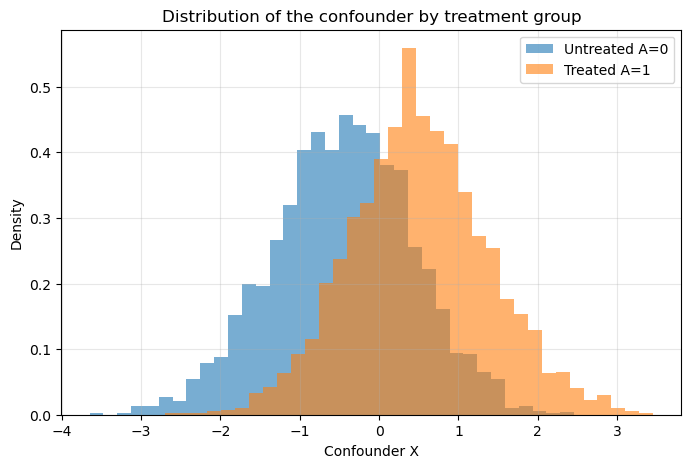

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["A"] == 0, "X"], bins=35, alpha=0.6, label="Untreated A=0", density=True)
plt.hist(df.loc[df["A"] == 1, "X"], bins=35, alpha=0.6, label="Treated A=1", density=True)
plt.xlabel("Confounder X")
plt.ylabel("Density")
plt.title("Distribution of the confounder by treatment group")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "01_confounder_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

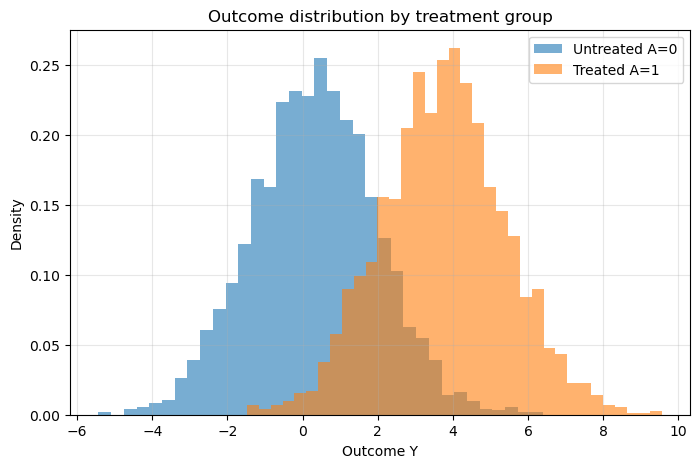

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["A"] == 0, "Y"], bins=35, alpha=0.6, label="Untreated A=0", density=True)
plt.hist(df.loc[df["A"] == 1, "Y"], bins=35, alpha=0.6, label="Treated A=1", density=True)
plt.xlabel("Outcome Y")
plt.ylabel("Density")
plt.title("Outcome distribution by treatment group")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "01_outcome_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Naive estimator versus adjusted regression

We compare two estimators:

1. **Naive difference in means**
$$
\mathbb{E}[Y \mid A=1] - \mathbb{E}[Y \mid A=0].
$$

2. **Adjusted regression**: a linear regression of `Y` on both `A` and `X`.

In [13]:
naive_diff = df.loc[df["A"] == 1, "Y"].mean() - df.loc[df["A"] == 0, "Y"].mean()

reg_naive = LinearRegression()
reg_naive.fit(df[["A"]], df["Y"])
naive_regression_effect = reg_naive.coef_[0]

reg_adjusted = LinearRegression()
reg_adjusted.fit(df[["A", "X"]], df["Y"])
adjusted_regression_effect = reg_adjusted.coef_[0]

estimates = {
    "Naive difference in means": naive_diff,
    "Naive regression Y~A": naive_regression_effect,
    "Adjusted regression Y~A+X": adjusted_regression_effect,
}
summary = summarize_estimates(estimates, TRUE_ATE)
summary

,Estimator,Estimate,True ATE,Bias,Absolute error
0,Naive difference in means,3.427128,2.0,1.427128,1.427128
1,Naive regression Y~A,3.427128,2.0,1.427128,1.427128
2,Adjusted regression Y~A+X,1.974069,2.0,-0.025931,0.025931


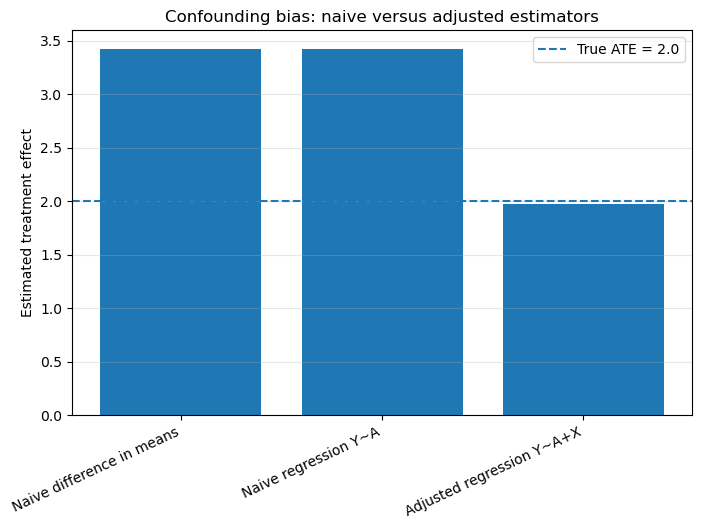

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(summary["Estimator"], summary["Estimate"])
plt.axhline(TRUE_ATE, linestyle="--", label=f"True ATE = {TRUE_ATE}")
plt.ylabel("Estimated treatment effect")
plt.title("Confounding bias: naive versus adjusted estimators")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.savefig(FIG_DIR / "01_estimator_comparison.png", dpi=300, bbox_inches="tight")
plt.show()